# 批量归一化

## 从零实现

In [2]:
# 导包
import torch
from torch import nn
from d2l import torch as d2l

# 参1：输入数据，参2：gamma参数，参3：beta参数，参4：移动平均值，参5：移动方差，参6：eps参数（黑马讲的小参数），参7：momentum参数
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    if not torch.is_grad_enabled():         # 模型当前处于模型评估（推理）阶段
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)         # 确保X的形状为2或4 -> 2维就是全连接层；4维就是卷积层
        if len(X.shape) == 2:       # 2维 -> 全连接层
            mean = X.mean(dim = 0)         # 计算均值 - 对全连接层，作用在特征维
            var = ((X - mean) ** 2).mean(dim = 0)         # 计算方差 - 对全连接层，作用在特征维
        else:                       # 4维 -> 卷积层
            mean = X.mean(dim = (0, 2, 3), keepdim = True)         # 计算均值 - 对卷积层，作用在通道维
            var = ((X - mean) ** 2).mean(dim = (0, 2, 3), keepdim = True)         # 计算方差 - 对卷积层，作用在通道维
        X_hat = (X - mean) / torch.sqrt(var + eps)         # 计算归一化值
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta
    return Y, moving_mean.data, moving_var.data

## 创建一个正确的`BatchNorm`图层

In [6]:
class BatchNorm(nn.Module):
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:       # 全连接层
            shape = (1, num_features)
        else:                   # 卷积层
            shape = (1, num_features, 1, 1)
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        if self.moving_mean.device != X.device:         # 把移动平均值和移动方差移动到和X相同的设备
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        Y, self.moving_mean, self.moving_var = batch_norm(      # 实体化一个batchnorm层
            X, self.gamma, self.beta, self.moving_mean,self.moving_var, eps=1e-5, momentum=0.9)
        return Y

## 应用`BatchNorm`于LeNet模型

In [21]:
net = nn.Sequential(
    nn.Conv2d(1, 6, 5),
    BatchNorm(6, num_dims = 4),             # 作用在全连接层和卷积层输出上，激活函数前
    nn.Sigmoid(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(6, 16, 5),
    BatchNorm(16, num_dims = 4),             # 作用在全连接层和卷积层输出上，激活函数前
    nn.Sigmoid(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(16 * 4 * 4, 120),
    BatchNorm(120, num_dims = 2),             # 作用在全连接层和卷积层输出上，激活函数前
    nn.Sigmoid(),
    nn.Linear(120, 84),
    BatchNorm(84, num_dims = 2),             # 作用在全连接层和卷积层输出上，激活函数前
    nn.Sigmoid(),
    nn.Linear(84, 10)
)

## 在Fashion-MNIST数据集上训练网络

In [22]:
lr, num_epochs, batch_size = 1.0, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
# d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 拉伸参数`gamma`和偏移参数`beta`

In [23]:
net[1].gamma.reshape((-1,)), net[1].beta.reshape((-1,))

(tensor([1., 1., 1., 1., 1., 1.], grad_fn=<ViewBackward0>),
 tensor([0., 0., 0., 0., 0., 0.], grad_fn=<ViewBackward0>))

## 简明实现

In [17]:
net = nn.Sequential(
    nn.Conv2d(1, 6, 5),
    nn.BatchNorm2d(6),             # 直接调用PyTorch的BatchNorm2d，就不用指定num_dims了，PyTorch内部会自动帮你指定
    nn.Sigmoid(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(6, 16, 5),
    nn.BatchNorm2d(16),             # 直接调用PyTorch的BatchNorm2d，就不用指定num_dims了，PyTorch内部会自动帮你指定
    nn.Sigmoid(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(16 * 4 * 4, 120),
    nn.BatchNorm2d(120),             # 直接调用PyTorch的BatchNorm2d，就不用指定num_dims了，PyTorch内部会自动帮你指定
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.BatchNorm2d(84),             # 直接调用PyTorch的BatchNorm2d，就不用指定num_dims了，PyTorch内部会自动帮你指定
    nn.Sigmoid(),
    nn.Linear(84, 10)
)

## 使用相同超参数来训练模型

loss 0.246, train acc 0.910, test acc 0.855
26325.6 examples/sec on cuda:0


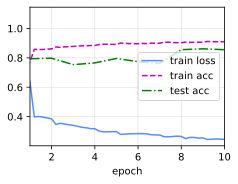

In [24]:
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())